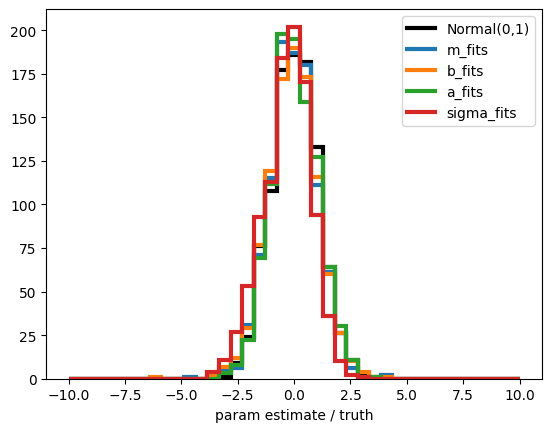

In [1]:
import numpy as np
from scipy.optimize import minimize
import os
ROOT_PATH = os.getcwd() + '/../'
import matplotlib.pyplot as plt


def mle_fit(x, y, sigma_i,x_pivot = 10,m_init= None,a_init = None, b_init= None,sigma_init = None,weights = None):
    """Fit y = m * (x - x_pivot) + b + N(0,sigma) + N(0,sigma_i) using MLE"""
    if weights is None:
        weights = np.ones_like(y) # weights should sum to len(y)
    def neg_log_likelihood(params):
        m, b, a, sigma = params
        if sigma <= 0:
            return np.inf
        # Total variance = sigma^2 + sigma_i^2
        total_var = sigma**2 + sigma_i**2
        # Predicted values
        y_pred = m * (x - x_pivot) + b + a * (x - x_pivot)**2
        # Log-likelihood (sum of log normal PDFs)
        log_lik = -0.5 * np.sum(weights * np.log(2 * np.pi * total_var) + (y - y_pred)**2 / total_var)
        return -log_lik
    
    # Initial guess
    guesses = np.polyfit(x - x_pivot, y, 2)
    if a_init is None:
        a_init =guesses[0]
    if m_init is None:
        m_init = guesses[1]
    if b_init is None:
        b_init = guesses[2]
    if sigma_init is None:
        sigma_init = np.std(y - np.polyval(guesses,x))
    
    # Optimize
    result = minimize(neg_log_likelihood, [m_init, b_init, a_init,sigma_init],
                     bounds=[(-300,300), (0,200), (-100,1000),(0, 300)]
                     )
    return result

TEST = 1
if TEST:
    m_fits = np.zeros(1000)
    b_fits = np.zeros(1000)
    a_fits = np.zeros(1000)
    sigma_fits = np.zeros(1000)
    for iir in range(1000):
        x = np.linspace(9,11,num = 100) # fake x vals 
        sigma_i = 50 * np.abs(x - 10)
        m_inj = -50
        b_inj = 50
        a_inj = 100
        sigma_inj = 40
        y = m_inj * (x-10) + b_inj + (x - 10)**2 * a_inj + (np.random.randn(x.size) * sigma_inj) + np.random.randn(x.size) * sigma_i # fake y vals: line plus DM_CBM scatter + sigma_cosmic scatter
        
        result = mle_fit(x, y, sigma_i,m_init = m_inj,b_init = b_inj, a_init = a_inj, sigma_init = 40)
        h_inv = result.hess_inv.todense()
        unc = np.sqrt(np.diag(h_inv))
        m_fit, b_fit, a_fit, sigma_fit = result.x    
        #print(f"Fitted parameters: m={m_fit:.3f}±{unc[0]:.3f} ({m_inj}), b={b_fit:.3f}±{unc[1]:.2f} ({b_inj}), sigma={sigma_fit:.3f}±{unc[2]:.2f} ({sigma_inj})")
        m_fits[iir] = (m_fit - m_inj) / unc[0]
        b_fits[iir] = (b_fit - b_inj) / unc[1]
        a_fits[iir] = (a_fit - a_inj) / unc[2]
        sigma_fits[iir] = (sigma_fit - sigma_inj) / unc[3]
    plt.figure()
    counts,bins =np.histogram(np.random.randn(1000),bins = np.linspace(-10,10,40))
    plt.stairs(counts,bins,linewidth = 3,color = 'black',label = 'Normal(0,1)')
    counts,bins = np.histogram(m_fits,bins = np.linspace(-10,10,40),)
    plt.stairs(counts,bins,label = 'm_fits',linewidth = 3)
    counts,bins = np.histogram(b_fits,bins = np.linspace(-10,10,40),)
    plt.stairs(counts,bins,label = 'b_fits',linewidth = 3)
    counts,bins = np.histogram(a_fits,bins = np.linspace(-10,10,40),)
    plt.stairs(counts,bins,label = 'a_fits',linewidth = 3)
    counts,bins = np.histogram(sigma_fits,bins = np.linspace(-10,10,40),)
    plt.stairs(counts,bins,label = 'sigma_fits',linewidth = 3)
    plt.xlabel('param estimate / truth')
    plt.legend()
    

Still needs M* measurement: Index([], dtype='object', name='name')
Subtracting mean: 9.862092064993089
Subtracting mean: 9.878311008448891
\dmhm &= (-128 \pm34)\log(M^*/10^{9.9} M_\odot) + (113\pm9)
\dmhm &= (-134 \pm43)\log(M^*/10^{9.9} M_\odot) + (92\pm23)
fo   message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 62.79363782360199
        x: [-1.385e+02  6.422e+01  3.581e+01  2.209e+00]
      nit: 5
      jac: [-8.114e-04  6.118e-04 -7.802e-04  3.780e-04]
     nfev: 35
     njev: 7
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>
ci   message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 50.00782661743116
        x: [-5.058e+01  9.794e+01 -1.260e+01  5.255e+01]
      nit: 19
      jac: [ 7.105e-07 -2.842e-06  0.000e+00 -7.105e-07]
     nfev: 110
     njev: 22
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>


/Users/calvinleung/pypeit_312_env/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0


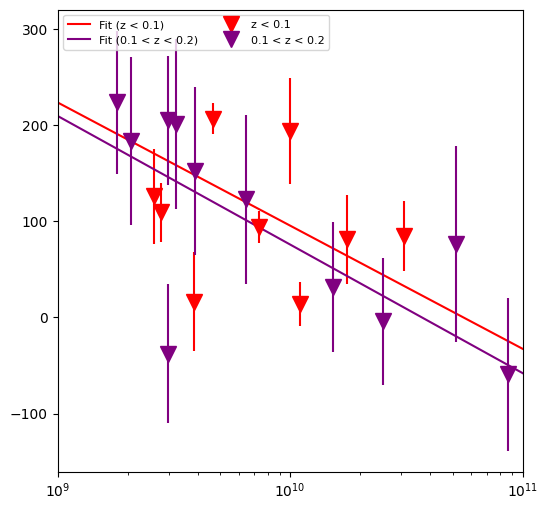

In [2]:
LOAD_DATA_FIT = 1
if LOAD_DATA_FIT:
    ROOT_PATH = os.getcwd() + '/..'
    import os
    from cltools import mpl
    import dmh_tools
    import pandas as pd
    import stack_tools
    _df = pd.read_csv(os.path.join(ROOT_PATH,'data_products/remove_clusters_lowdm_edgeon.csv'))
    _df.set_index('name',inplace=True)
    keep = dmh_tools.not_clusters(_df) * dmh_tools.not_edge_on(_df) * dmh_tools.not_scattered(_df) * dmh_tools.not_elliptical(_df) * dmh_tools.not_low_dm(_df) * dmh_tools.not_dwarf(_df)
    df = _df[keep]

    plot_mstar = 10**dmh_tools.best_stellar_mass(df)
    plot_dm = df['DM_host_restframe']
    plot_dmerr = dmh_tools.sigma_tot(df)
    
    # Plot theory outputs
    plt.figure(figsize = mpl.figsize(journal = 'apj',fraction_of_textwidth = 1,height_per_width=1))
    plt.xscale('log')
    ci = df['primary_z_spec'] < 0.1
    fo = (0.1 < df['primary_z_spec']) * (df['primary_z_spec'] < 0.2) #* (df.index != 'FRB20231201A')
    mxpb_ci = stack_tools.fit_linear_with_uncertainties(df[ci])
    mxpb_fo = stack_tools.fit_linear_with_uncertainties(df[fo])
    mstar_line = np.linspace(9,11)
    stack_tools.get_eqn_string(mxpb_ci)
    stack_tools.get_eqn_string(mxpb_fo)
    
    plt.errorbar(x = plot_mstar[ci],y = plot_dm[ci],yerr = plot_dmerr[ci], linestyle = 'none',marker = 'v',color = 'red',label = 'z < 0.1',markersize = 12)
    plt.plot(10**mstar_line, mxpb_ci['intercept'] + mxpb_ci['slope'] * (mstar_line - mxpb_ci['x_mean']),color = 'red',label = 'Fit (z < 0.1)')

    plt.errorbar(x = plot_mstar[fo],y = plot_dm[fo],yerr = plot_dmerr[fo], linestyle = 'none',marker = 'v',color = 'purple',label = '0.1 < z < 0.2',markersize = 12)
    plt.plot(10**mstar_line, mxpb_fo['intercept'] + mxpb_fo['slope'] * (mstar_line - mxpb_fo['x_mean']),color = 'purple',label = 'Fit (0.1 < z < 0.2)')
    #ax2 = ax1.twinx()
    #ax2.set_ylabel(r'$DM_{h}$',color = 'red')
    #ax2.tick_params(axis='y', colors='red',left = False, right = True)
    #ax2.set_ylim(-150,350)
    plt.legend(loc = 'upper left',ncols = 2,fontsize = 8)
    plt.xlim(1e9,1e11)
    print(stack_tools.get_eqn_string(mxpb_ci))
    print(stack_tools.get_eqn_string(mxpb_fo))
    res_fo = mle_fit(x = np.log10(plot_mstar[fo]), y = plot_dm[fo], sigma_i = plot_dmerr[fo],x_pivot = 10,m_init = mxpb_fo['slope'],b_init = mxpb_fo['intercept'],sigma_init = 10)
    res_ci = mle_fit(x = np.log10(plot_mstar[ci]), y = plot_dm[ci], sigma_i = plot_dmerr[ci],x_pivot = 10,m_init = mxpb_ci['slope'],b_init = mxpb_ci['intercept'],sigma_init = 10)
    

    print('fo',res_fo)
    print('ci',res_ci)

In [3]:
plot_mstar = 10**dmh_tools.best_stellar_mass(df)
plot_dm = df['DM_host_restframe']
plot_dmerr = dmh_tools.sigma_tot(df)
REDO_FIG = 0
all_bminmax = [[0.10,0.20],[0.13,0.20],[0.10,0.16]]
M_star_cen = np.geomspace(1e9,8e10,num = 7)
all_snaps = ['090','088','086','084','082']
models = ['Astrid','IllustrisTNG','SIMBA']
plot_weightindex = 2
import camels_tools
# Plot theory outputs
plt.figure(figsize = mpl.figsize(journal = 'apj',fraction_of_textwidth = 1,height_per_width=1))
if REDO_FIG:
    def append_fill_between(x,y1,y2,xa,**kwargs):
        y1 = np.concatenate((y1,np.atleast_1d(y1[-1])))
        y2 = np.concatenate((y2,np.atleast_1d(y2[-1])))
        x = np.concatenate((x,np.atleast_1d(xa)))
        plt.fill_between(x,y1,y2,**kwargs)
        
    for ii,model in enumerate(['Astrid','IllustrisTNG','SIMBA']):
        for snap_id in all_snaps:
            snap_z = camels_tools.CAMELS_REDSHIFTS[snap_id]
            for b_min,b_max in all_bminmax:
                #res = camels_tools.plot_theory_predictions(f'/Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/Astrid_1P_3_0_snap{snap_id}_haloDM_b={bb:.2f}.h5',
                #                ax = plt.gca(),alpha = 0.2,facecolor = 'C0',label = 'Astrid')
                stack_path = f'/Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/{model}_1P_3_0_snap{snap_id}_haloDM' + f'_bminmax={b_min:.2f}_{b_max:.2f}.h5'
    
                res = camels_tools.from_file(stack_path)
                bin_cen = np.sqrt(res['M_star_bins'][:,0] * res['M_star_bins'][:,1])
                xa =res['M_star_bins'][-1,-1] # add endpoint of last bin for plotting only
                # if fiducial
                if b_min == 0.10 and b_max == 0.16 and snap_z == 0.1:
                    append_fill_between(bin_cen,
                        res['weighted_mean'][plot_weightindex,:] -res['weighted_std'][plot_weightindex,:],
                        res['weighted_mean'][plot_weightindex,:] +res['weighted_std'][plot_weightindex,:],
                        xa = xa,
                        alpha = 0.1,
                        color = f'C{ii}', label = model,linewidth = 3,step = 'mid')
                    plt.plot(bin_cen, res['weighted_mean'][plot_weightindex,:],color = f'C{ii}',linewidth = 3,marker = '^',markersize = 12,markerfacecolor='white',label = 'Fiducial')
                else:
                    append_fill_between(bin_cen,
                        res['weighted_mean'][plot_weightindex,:] -res['weighted_std'][plot_weightindex,:],
                        res['weighted_mean'][plot_weightindex,:] +res['weighted_std'][plot_weightindex,:],
                        xa = xa,
                        alpha = 0.1,
                        color = f'C{ii}',step = 'mid')
                    plt.plot(bin_cen, res['weighted_mean'][plot_weightindex,:],color = f'C{ii}',linewidth = 1)
                #res = camels_tools.plot_theory_predictions(stack_path,
                #                ax = plt.gca(),alpha = 0.2,facecolor = 'C1',label = 'IllustrisTNG')    
        plt.xscale('log')
        plt.xlim(1.3e9,1e11)
        plt.ylim(-150,370)
        plt.xlabel(r'$M^*$')
        ax1 = plt.gca()
        ax1.set_ylabel(r'$DM_{h,CGM}$ or $DM_{h}$',color = 'black')
        ax1.legend(loc = 'lower center',ncols = 4,fontsize = 8)
    
        plt.savefig(f'/Users/calvinleung/kko_host_paper/figures/msdm_{ii}.png',dpi = 110,bbox_inches='tight')

Still needs M* measurement: Index([], dtype='object', name='name')


<Figure size 600x600 with 0 Axes>

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

def func(x,m,b,a,x_pivot = 10):
    return a * (x - x_pivot)**2 + m * (x - x_pivot) + b
    
def log_likelihood(params, x, y, sigma_i, weight_i):
    """Log-likelihood for y = mx + b + N(0,sigma) + N(0,sigma_i)
    
    Assumes weights add to len(x)."""
    m, b, a, sigma = params
    if sigma <= 0:
        return -np.inf
    total_var = sigma**2 + sigma_i**2
    y_pred = func(x,m,b,a,x_pivot = 10)
    return -0.5 * np.sum(weight_i * np.log(2 * np.pi * total_var) + (y - y_pred)**2 / total_var)

def log_prior(params):
    """Uniform priors"""
    m, b, a, sigma = params
    if -300 < m < 300 and -150 < b < 250 and 1 < sigma < 200 and -1000 < a < 1000:
        return 1/sigma
    return -np.inf

def log_posterior(params, x, y, sigma_i,weight_i):
    """Log-posterior = log-likelihood + log-prior"""
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params, x, y, sigma_i,weight_i)

# Initialize walkers


def run_emcee_fit(x,y,sigma_i,weight_i = None,initial_guesses = [2.0,0.0,0.5,20],out_file = None,variant_name = 'default', steps = 2000, **corner_kwargs):
    ndim, nwalkers = 4, 50
    p0 = np.random.randn(nwalkers, ndim) * 10 + np.atleast_1d(initial_guesses) # must be of length 4
    # Run MCMC
    if weight_i is None:
        weight_i = np.ones_like(x)
    print('weights',weight_i)
    if out_file is None:
        backend = None
    else:
        backend = emcee.backends.HDFBackend(out_file,name = variant_name)
        backend.reset(nwalkers, ndim)    
        print(backend.name)
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(x, y, sigma_i,weight_i),backend = backend)
    sampler.run_mcmc(p0, steps, progress=True)



    # Extract samples (discard burn-in)
    samples = sampler.get_chain(discard=500, flat=True)
    return samples
    

    return samples

def get_table_entry(name,p16,p50,p84):
    return f"${name} = {p50:.1f}" + "^{+" + f"{p84 - p50:.1f}" + "}_{-" + f"{p50-p16:.1f}" + "}$"

def get_params(samples):
    # Print results
    m_mcmc, b_mcmc, a_mcmc, sigma_mcmc = np.median(samples, axis=0)
    print(f"MCMC results: m={m_mcmc:.3f}, b={b_mcmc:.3f}, a={a_mcmc:.3f}, sigma={sigma_mcmc:.3f}")
    print(f"16-84% percentiles:")
    for i, param in enumerate(["m", "b", "a", "sigma"]):
        p16, p50, p84 = np.percentile(samples[:, i], [16, 50, 84])
        print(get_table_entry(param,p16,p50,p84))
    return m_mcmc, b_mcmc, a_mcmc, sigma_mcmc




In [8]:
import pandas as pd

import dmh_tools

from cltools import mpl
import importlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import camels_tools
import stack_tools
import dmh_tools
from camels_tools import analyze_halos,load_snapshot,plot_theory_predictions
from camels_tools import from_file
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import os
import pandas as pd
import dmh_tools
%matplotlib ipympl
from glob import glob

# Do the stacking, 
# Write to .h5

all_bminmax = [[0.10,0.20],[0.13,0.20],[0.10,0.16]]
M_star_cen = np.geomspace(1e9,8e10,num = 7)
all_snaps = ['090','088','086','084','082']
models = ['Astrid','IllustrisTNG','SIMBA']

In [9]:
def analyze_halos_mle(
    df: pd.DataFrame,
    num_halos: int,
    b_min: float,
    b_max: float,
    M_200_min: float,
    M_200_max: float,
    M_star_min: float,
    M_star_max: float,
    sfr_min: float,
    sfr_max: float,
    weightings = ['uniform','M_star','sfr','both'],
    out_file: str = None,
    random_seed: int = 42,
    oversample: int = 0,
    verbose = True,
    variant_name = 'default',
    **corner_kwargs
    ):
    """
    Analyze halos from a CSV file with filtering and weighting.
    
    Parameters:
    -----------
    df : DataFrame
        To be analyzed
    num_halos : int
        Number of halos to randomly sample
    b_min, b_max : float
        Min and max impact parameter values to filter
    M_200_min, M_200_max : float
        Min and max M_200 values to filter
    sfr_min, sfr_max : float
        Min and max SFR values to filter
    random_seed : int, optional
        Random seed for reproducibility
    variant_name : str
        What to write to the H5 file
        
    Returns:
    --------
    results : dict
        Dictionary containing analysis results
    sampled_data : pd.DataFrame
        The sampled data that was used for analysis
    """
    # Set random seed for reproducibility
    #np.random.seed(random_seed)
    df['dm_total'] = df['dm_total'] / 2 # DIVIDE BY 2
    
    # 1. Initial cuts on the data
    
    filtered_df = df[
            (df['b_val'] >= b_min) & 
            (df['b_val'] <= b_max) & 
            ((df['M_200'] >= M_200_min) + np.isnan(df['M_200'])) & 
            ((df['M_200'] <= M_200_max) + np.isnan(df['M_200'])) & 
            ((df['sfr'] >= sfr_min) + np.isnan(df['sfr'])) & 
            ((df['sfr'] <= sfr_max) + np.isnan(df['sfr'])) &
            (df['M_star'] >= M_star_min) &
            (df['M_star'] <= M_star_max)
        ]
    print('Dividing by 2')
    # 2. Sample: one sightline per halo, not one per unit area.
    sampled_data = filtered_df.set_index('halo_index').groupby('halo_index').apply(lambda x: x.sample(n=1,)).reset_index(drop=True)
    if oversample:
        print('Oversampling by a factor of',oversample)
        oversamples = []
        for iisample in range(oversample):
            oversamples.append(filtered_df.set_index('halo_index').groupby('halo_index').apply(lambda x: x.sample(n=1,)).reset_index(drop=True))
        sampled_data = pd.concat(oversamples,ignore_index=True,sort = False)

    if len(sampled_data) < num_halos:
        print(
            f"Not enough halos after filtering ({len(sampled_data)} < {num_halos})"
            )
    print(f'sightlines within halos: {len(filtered_df)}, unique halos: {len(set(filtered_df['halo_index']))}, sampled sightlines: {len(sampled_data.index)}')
    plt.figure()
    mcmc_samples = np.zeros((len(weightings),75000,4))
    for iiweighting, weighting in enumerate(weightings):
        if weighting == 'uniform':
            weights = np.ones_like( sampled_data['M_star']) / len( sampled_data['M_star'])
        if weighting == 'M_star':
            weights = sampled_data['M_star'] / sampled_data['M_star'].sum()
        if weighting == 'sfr':
            weights = sampled_data['sfr'] / sampled_data['sfr'].sum()
        if weighting == 'both':
            weights = sampled_data['sfr'] * sampled_data['M_star'] / (sampled_data['sfr'] * sampled_data['M_star']).sum()
        weights *= len(sampled_data['M_star'])
        
        res = mle_fit(x = np.log10(sampled_data['M_star']),y = sampled_data['dm_total'],
                      sigma_i = np.zeros_like(sampled_data['dm_total']),weights = weights)
        mcmc_samples[iiweighting] = run_emcee_fit(
            x = np.log10(sampled_data['M_star']),y = sampled_data['dm_total'],
            sigma_i = np.zeros_like(sampled_data['dm_total']),weight_i = weights,
            initial_guesses = [res.x[0],res.x[1],res.x[2],res.x[3]],variant_name = variant_name,out_file = out_file
        )
        with h5py.File(out_file,'r+') as f:
            print('Writing out data from the snapshot we just analyzed...')
            f.create_dataset(variant_name + '/sfr',data = sampled_data['sfr'].values)
            f.create_dataset(variant_name + '/M_star',data = sampled_data['M_star'].values)
            f.create_dataset(variant_name + '/M_200',data = sampled_data['M_200'].values)
            f.create_dataset(variant_name + '/dm_total',data = sampled_data['dm_total'].values)
    return mcmc_samples,sampled_data



# New Fig 2

Still needs M* measurement: Index([], dtype='object', name='name')
MCMC results: m=-98.227, b=89.784, a=-16.087, sigma=58.307
16-84% percentiles:
$m = -98.2^{+43.1}_{-42.1}$
$b = 89.8^{+26.8}_{-26.5}$
$a = -16.1^{+91.4}_{-92.3}$
$sigma = 58.3^{+20.0}_{-14.6}$


NameError: name 'x_line' is not defined

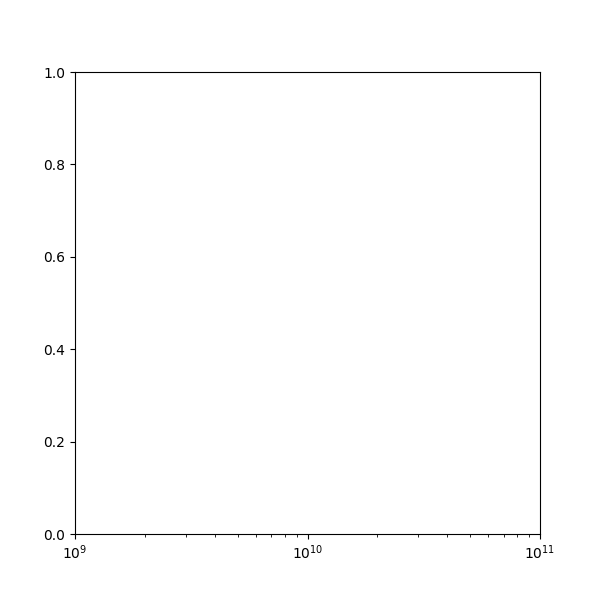

In [11]:
import os
from cltools import mpl
import h5py
import dmh_tools
import pandas as pd
import stack_tools
_df = pd.read_csv(os.path.join(ROOT_PATH,'data_products/remove_clusters_lowdm_edgeon.csv'))
_df.set_index('name',inplace=True)
keep = dmh_tools.not_clusters(_df) * dmh_tools.not_edge_on(_df) * dmh_tools.not_scattered(_df) * dmh_tools.not_elliptical(_df) * dmh_tools.not_low_dm(_df) * dmh_tools.not_dwarf(_df)
df = _df[keep]

plot_mstar = 10**dmh_tools.best_stellar_mass(df)
plot_dm = df['DM_host_restframe']
plot_dmerr = dmh_tools.sigma_tot(df)
    
# Plot data
plt.figure(figsize = mpl.figsize(journal = 'apj',fraction_of_textwidth = 1,height_per_width=1))
plt.xscale('log')
ci = df['primary_z_spec'] < 0.1
fo = (0.1 < df['primary_z_spec']) * (df['primary_z_spec'] < 0.2) #* (df.index != 'FRB20231201A')
mstar_line = np.linspace(9,11)
plt.xlim(1e9,1e11)
ax = plt.gca()

out_file = ROOT_PATH+'/data_products/mcmc_data.h5'
with h5py.File(out_file,'r') as f:
    mcmc_samples = f['fiducial']['chain'][:].reshape((-1,4))[500:,:]
    m,b,a,s = get_params(mcmc_samples)
    # Plot Best Fit Values
    ax.plot(10**x_line,func(x_line,m = m,b = b, a = a) - s, alpha = 1,color = 'gray',zorder = 2)
    ax.plot(10**x_line,func(x_line,m = m,b = b, a = a), alpha = 1,color = f'gray',label = 'Data (best fit)',zorder = 2)
    ax.plot(10**x_line,func(x_line,m = m, b = b, a = a) + s, alpha = 1,color = f'gray',zorder = 2) 
    for iisample in range(50):
        (m,b,a,s) = mcmc_samples[75 * iisample]
        ax.fill_between(10**x_line,func(x_line,m = m,b = b, a = a) - s, func(x_line,m = m, b = b, a = a) + s, alpha = 0.02,color = f'gray')
ax.errorbar(x = plot_mstar[ci],y = plot_dm[ci],yerr = plot_dmerr[ci], linestyle = 'none',marker = 'v',color = 'red',label = 'Data (z < 0.1)',markersize = 12)
ax.errorbar(x = plot_mstar[fo],y = plot_dm[fo],yerr = plot_dmerr[fo], linestyle = 'none',marker = 'v',color = 'purple',label = 'Data (0.1 < z < 0.2)',markersize = 12)

for iisim,sim in enumerate(['Astrid',
                            'IllustrisTNG',
                            'SIMBA'
                           ]):
    filepath = glob(ROOT_PATH+f'/data_products/camels_data/20250502/{sim}_1P_3_0_snap088*noISM.csv')[0]
    sim_df = camels_tools.load_snapshot(filepath,names = camels_tools.MAY_HEADER)
    for bb in [[0.00,0.05],
               #[0.05,0.1],
               #[0.1,0.15],
               #[0.15,0.2]
              ]:
        out_file = ROOT_PATH+'/data_products/mcmc_sims.h5'
        variant_name = f'{sim}_{bb[0]:.2f}_{bb[1]:.2f}_sfr_no_ism'
        with h5py.File(out_file,'r') as f:
            mcmc_samples = f[variant_name]['chain'][:].reshape((-1,4))[500:,:]
            m_star = f[variant_name]['M_star'][:]
            sfr = f[variant_name]['sfr']
            m_200 = f[variant_name]['M_200']
            dm = f[variant_name]['dm_total']
            ax.scatter(m_star, dm, color = f'C{iisim}',alpha = 1, label = sim + ' (halos)',s = 5)
            x_line = np.linspace(9,11)
            m,b,a,s = get_params(mcmc_samples)
            # Plot Best Fit Values
            ax.plot(10**x_line,func(x_line,m = m,b = b, a = a) - s, alpha = 1,color = f'C{iisim}',zorder = 1)
            ax.plot(10**x_line,func(x_line,m = m,b = b, a = a), alpha = 1,color = f'C{iisim}',label = sim + ' (best fit)',zorder = 1)
            ax.plot(10**x_line,func(x_line,m = m, b = b, a = a) + s, alpha = 1,color = f'C{iisim}',zorder = 1) 
            for iisample in range(50):
                (m,b,a,s) = mcmc_samples[75 * iisample]
                ax.fill_between(10**x_line,func(x_line,m = m,b = b, a = a) - s, func(x_line,m = m, b = b, a = a) + s, alpha = 0.01,color = f'C{iisim}')
ax.set_ylim(-100,370)
ax.set_xlabel(r'$M^* / M_\odot$')

ax.set_ylabel(r'$\mathrm{DM_h}$ or $\mathrm{DM_{CGM}}$',color = 'black')
ax.legend(loc = 'upper right',ncols = 2,fontsize = 8)
plt.tight_layout()
plt.savefig(ROOT_PATH+'/figures/msdm.pdf',dpi = 110)
plt.savefig(ROOT_PATH+'/figures/msdm.png',dpi = 110)



# New Fig 3

MCMC results: m=-98.227, b=89.784, a=-16.087, sigma=58.307
16-84% percentiles:
$m = -98.2^{+43.1}_{-42.1}$
$b = 89.8^{+26.8}_{-26.5}$
$a = -16.1^{+91.4}_{-92.3}$
$sigma = 58.3^{+20.0}_{-14.6}$


MCMC results: m=84.008, b=90.975, a=32.018, sigma=26.949
16-84% percentiles:
$m = 84.0^{+6.9}_{-6.8}$
$b = 91.0^{+3.1}_{-3.1}$
$a = 32.0^{+9.8}_{-9.9}$
$sigma = 26.9^{+1.6}_{-1.4}$
MCMC results: m=2.543, b=50.215, a=-15.269, sigma=26.745
16-84% percentiles:
$m = 2.5^{+5.3}_{-5.3}$
$b = 50.2^{+3.1}_{-3.1}$
$a = -15.3^{+9.3}_{-9.4}$
$sigma = 26.7^{+1.6}_{-1.5}$
MCMC results: m=1.928, b=23.362, a=-6.710, sigma=19.367
16-84% percentiles:
$m = 1.9^{+2.9}_{-2.9}$
$b = 23.4^{+2.1}_{-2.0}$
$a = -6.7^{+5.2}_{-5.3}$
$sigma = 19.4^{+1.0}_{-0.9}$


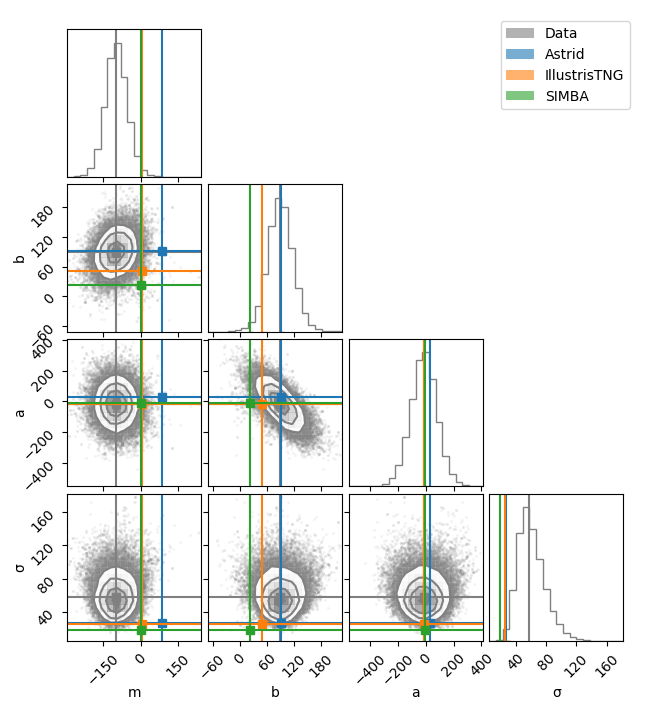

In [17]:
fig = plt.figure(figsize = mpl.figsize(fraction_of_textwidth=1,height_per_width = 1.1))
with h5py.File( ROOT_PATH+'/data_products/mcmc_data.h5', "r") as f:
    fid_samples = f['fiducial']['chain'][:].reshape((-1,4))[500:,:]
    ci_samples = f['ci']['chain'][:].reshape((-1,4))[1000::2,:]
    fo_samples = f['fo']['chain'][:].reshape((-1,4))[1000::2,:]    
    m_mcmc, b_mcmc, a_mcmc, sigma_mcmc = get_params(fid_samples)
    corner.corner(fid_samples[::4], labels=["m", "b", "a","σ"], truths=[m_mcmc, b_mcmc, a_mcmc, sigma_mcmc],color = 'gray',fig = fig,alpha = 0.1,truth_color='gray')
    from matplotlib.patches import Patch
    with h5py.File( ROOT_PATH+'/data_products/mcmc_sims.h5', "r") as f:
        for iikey,key in enumerate([
                    'Astrid_0.00_0.05_sfr_no_ism',
                    'IllustrisTNG_0.00_0.05_sfr_no_ism',
                    'SIMBA_0.00_0.05_sfr_no_ism']):
            samples = f[key]['chain'][:].reshape((-1,4))[500:,:]
            m_mcmc, b_mcmc, a_mcmc, sigma_mcmc = get_params(samples)
            corner.corner(samples[0:5,:], labels=["m", "b", "a","σ"], truths=[m_mcmc, b_mcmc, a_mcmc, sigma_mcmc],color = f'C{iikey}',fig = fig,alpha = 0.0,truth_color = f'C{iikey}')
    legend_elements = [Patch(facecolor='gray', alpha=0.6, label='Data'),
                       Patch(facecolor='C0', alpha=0.6, label='Astrid'),
                       Patch(facecolor='C1', alpha=0.6, label='IllustrisTNG'),
                       Patch(facecolor='C2', alpha=0.6, label='SIMBA'),]
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))
plt.savefig(ROOT_PATH+'/figures/corner.pdf',dpi = 110)
plt.savefig(ROOT_PATH+'/figures/corner.png',dpi = 110)

In [18]:
# GENERATE MODEL PREDICTIONS -> mcmc_sims.h5
GET_MODEL_PREDICTIONS = 0
if GET_MODEL_PREDICTIONS:
    mcmc_samples = np.zeros((3,75000,4))
    f = plt.figure()
    ax = plt.gca()
    for iisim,sim in enumerate(['Astrid',
                                'IllustrisTNG',
                                'SIMBA'
                               ]):
        filepath = glob(ROOT_PATH+f'/data_products/camels_data/20250502/{sim}_1P_3_0_snap088*noISM.csv')[0]
        sim_df = camels_tools.load_snapshot(filepath,names = camels_tools.MAY_HEADER)
        for bb in [[0.00,0.05],
                   [0.05,0.1],
                   [0.1,0.15],
                   [0.15,0.2]
                  ]:
            out_file = ROOT_PATH+'/data_products/mcmc_sims.h5'
            variant_name = f'{sim}_{bb[0]:.2f}_{bb[1]:.2f}_sfr_no_ism'
            mcmc_samples[iisim],sampled_halos = analyze_halos_mle(sim_df,
                          num_halos = 10,
                          b_min = bb[0],
                          b_max = bb[1],
                          M_200_min = 0,
                          M_200_max = np.inf,
                          M_star_min = 1e9,
                          M_star_max =1e11,
                          sfr_min = 0, sfr_max = np.inf,weightings=['sfr'],out_file = out_file, variant_name = variant_name,
            )
            ax.scatter(np.log10(sampled_halos['M_star']),sampled_halos['dm_total'],color = f'C{iisim}',alpha = 0.15,marker = ',',s = 5)
        x = np.log10(sampled_halos['M_star'])
        y = sampled_halos['dm_total']
        x_line = np.linspace(9,11)
        m,b,a,s = get_params(mcmc_samples[iisim])
        ax.plot(x_line,func(x_line,m = m,b = b, a = a) - s, alpha = 1,color = f'C{iisim}')
        ax.plot(x_line,func(x_line,m = m,b = b, a = a), alpha = 1,color = f'C{iisim}',label = sim + ' Fiducial')
        ax.plot(x_line,func(x_line,m = m, b = b, a = a) + s, alpha = 1,color = f'C{iisim}')
        for iisample in range(100):
            (m,b,a,s) = mcmc_samples[iisim,75 * iisample]
            ax.fill_between(x_line,func(x_line,m = m,b = b, a = a) - s, func(x_line,m = m, b = b, a = a) + s, alpha = 0.007,color = f'C{iisim}')
    ax.set_xlim(9,11)
    ax.set_xlabel(r'$M^* / M_\odot$')
    
    ax.set_ylabel(r'$DM_{h,CGM}$',color = 'black')
    ax.legend(loc = 'lower center',ncols = 4,fontsize = 8)
    


# Make Fig 4

In [22]:
import numpy as np

def write_latex_header(filename, param_names=['$m$', '$b$', '$a$', '$\\sigma$']):
    """
    Write LaTeX table header to file.
    
    Parameters:
    -----------
    filename : str
        Output filename
    param_names : list
        List of parameter names in LaTeX format
    """
    with open(filename, 'w') as f:
        f.write('\\begin{table*}[htbp]\n')
        f.write('\\centering\n')
        f.write('\\begin{tabular}{|c|' + 'c|' * len(param_names) + '}\n')
        f.write('\\hline\n')
        f.write('Model & ' + ' & '.join(param_names) + ' \\\\\n')
        f.write('\\hline\n')

def write_parameter_row(filename, mcmc_samples, model_name, percentiles=[16, 50, 84]):
    """
    Format and write a row of parameter estimates with asymmetric uncertainties.
    
    Parameters:
    -----------
    filename : str
        Output filename (file will be appended to)
    mcmc_samples : array-like
        MCMC samples array with shape (n_samples, n_parameters)
        Expected parameter order: [m, b, a, sigma]
    model_name : str
        Name of the model for the table row
    percentiles : list
        Percentiles for uncertainty estimation [lower, median, upper]
    """
    samples = np.array(mcmc_samples)
    
    # Calculate percentiles for each parameter
    param_stats = np.percentile(samples, percentiles, axis=0)
    lower, median, upper = param_stats
    
    # Format each parameter with asymmetric uncertainties
    param_strings = []
    for i in range(samples.shape[1]):
        med = median[i]
        lower_err = med - lower[i]
        upper_err = upper[i] - med
        
        # Format with appropriate precision
        if abs(lower_err) < 10:
            param_str = f"${med:.1f}^{{+{upper_err:.1f}}}_{{-{lower_err:.1f}}}$"
        else:
            param_str = f"${med:.0f}^{{+{upper_err:.0f}}}_{{-{lower_err:.0f}}}$"
        
        param_strings.append(param_str)
    
    # Write row to file
    with open(filename, 'a') as f:
        f.write(model_name + " & " + " & ".join(param_strings) + " \\\\\n")

def close_latex_table(filename, caption="Parameter estimates", label="tab:params"):
    """
    Close the LaTeX table with footer.
    
    Parameters:
    -----------
    filename : str
        Output filename
    caption : str
        Table caption
    label : str
        Table label for referencing
    """
    with open(filename, 'a') as f:
        f.write('\\hline\n')
        f.write('\\end{tabular}\n')
        f.write(f'\\caption{{{caption}}}\n')
        f.write(f'\\label{{{label}}}\n')
        f.write('\\end{table*}\n')


In [21]:
# RUN ALL VARIANTS
LOAD_AND_RUN_VARIANTS = 1
if LOAD_AND_RUN_VARIANTS: 
    _df = pd.read_csv(os.path.join(ROOT_PATH,'data_products/remove_clusters_lowdm_edgeon.csv'))
    _df.set_index('name',inplace=True)
    keep = dmh_tools.not_clusters(_df) * dmh_tools.not_edge_on(_df) * dmh_tools.not_scattered(_df) * dmh_tools.not_elliptical(_df) * dmh_tools.not_low_dm(_df) * dmh_tools.not_dwarf(_df)
    df = _df[keep]
    ci = df['primary_z_spec'] < 0.1
    fo = (0.1 < df['primary_z_spec']) * (df['primary_z_spec'] < 0.2) #* (df.index != 'FRB20231201A')
    nt = (df.index != 'FRB20210807D') # NOT transitioning galaxies? This is a weird one
    log10mstar = dmh_tools.best_stellar_mass(df)
    plot_dm = df['DM_host_restframe']
    plot_dmerr = dmh_tools.sigma_tot(df)
    
    out_file = ROOT_PATH+'/data_products/mcmc_data.h5'
    if os.path.exists(out_file):
        os.remove(out_file)
    fiducial_samples = run_emcee_fit(x = log10mstar,y = plot_dm,sigma_i = plot_dmerr,weightings = ['sfr'],out_file =out_file,variant_name = 'fiducial',steps = 5000)
    fo_samples = run_emcee_fit(x = log10mstar[fo],y = plot_dm[fo],sigma_i = plot_dmerr[fo],weightings = ['sfr'],out_file =out_file,variant_name = 'fo', steps = 5000)
    ci_samples = run_emcee_fit(x = log10mstar[ci],y = plot_dm[ci],sigma_i = plot_dmerr[ci],weightings = ['sfr'],out_file =out_file,variant_name = 'ci',steps = 5000)
    hsc_samples = run_emcee_fit(x = log10mstar,y = plot_dm,sigma_i = plot_dmerr * 1.5,weightings = ['sfr'],out_file =out_file,variant_name = 'high_sigma', steps = 5000)
    csc_samples = run_emcee_fit(x = log10mstar,y = plot_dm,sigma_i = plot_dmerr * 0 + 80,weightings = ['sfr'],out_file =out_file,variant_name = 'constant_sigma',steps = 5000)
    ldc_samples = run_emcee_fit(x = log10mstar,y = plot_dm + 0.3 * df['dm_igm'],sigma_i = plot_dmerr ,weightings = ['sfr'],out_file =out_file,variant_name = 'low_dm_cosmic',steps = 5000)
    hdc_samples = run_emcee_fit(x = log10mstar,y = plot_dm - 0.3 * df['dm_igm'],sigma_i = plot_dmerr ,weightings = ['sfr'],out_file =out_file,variant_name = 'high_dm_cosmic',steps = 5000)

    goldgold = ~(df['primary_P_Ox'] < 0.95) # need "not less than 0.95" to include nans
    gg_samples = run_emcee_fit(x = log10mstar[goldgold],y = plot_dm[goldgold],sigma_i = plot_dmerr[goldgold] ,weightings = ['sfr'],out_file =out_file,variant_name = 'pox_95',steps = 5000)
    nt_samples = run_emcee_fit(x = log10mstar[nt],y = plot_dm[nt],sigma_i = plot_dmerr[nt] ,weightings = ['sfr'],out_file =out_file,variant_name = 'nt',steps = 5000)
    #low_mass = log10mstar < 10
    #high_mass = log10mstar >= 10
    #low_end = run_emcee_fit(x = log10mstar[low_mass],y = plot_dm[low_mass],sigma_i = plot_dmerr[low_mass] ,weightings = ['sfr'],out_file =out_file,variant_name = 'low_end')
    #high_end = run_emcee_fit(x = log10mstar[high_mass],y = plot_dm[high_mass],sigma_i = plot_dmerr[high_mass] ,weightings = ['sfr'],out_file =out_file,variant_name = 'high_end')

Still needs M* measurement: Index([], dtype='object', name='name')
weights [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
fiducial


  0%|                                                                                                                                                                          | 0/5000 [00:00<?, ?it/s]/Users/calvinleung/pypeit_312_env/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:40<00:00, 123.53it/s]


weights [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
fo


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:37<00:00, 132.51it/s]


weights [1. 1. 1. 1. 1. 1. 1. 1. 1.]
ci


...

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:41<00:00, 121.32it/s]


weights [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
pox_95


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:42<00:00, 117.30it/s]


weights [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
nt


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:44<00:00, 113.45it/s]


<>:144: SyntaxWarning: invalid escape sequence '\s'
<>:144: SyntaxWarning: invalid escape sequence '\s'
/var/folders/2v/13b457dx6qn34sd445522vnc0000gp/T/ipykernel_1821/987724709.py:144: SyntaxWarning: invalid escape sequence '\s'
  caption = "MCMC parameter estimates for observed and simulated sightlines, where we fit the slope ($m$), intercept ($b$), curvature ($a$), and scatter ($\sigma$)."


fiducial
MCMC results: m=-97.060, b=89.404, a=-10.814, sigma=59.194
16-84% percentiles:
$m = -97.1^{+43.7}_{-43.7}$
$b = 89.4^{+27.2}_{-27.0}$
$a = -10.8^{+94.1}_{-93.3}$
$sigma = 59.2^{+19.6}_{-14.9}$
low_dm_cosmic
MCMC results: m=-97.687, b=102.861, a=17.738, sigma=59.884
16-84% percentiles:
$m = -97.7^{+43.4}_{-43.5}$
$b = 102.9^{+28.0}_{-26.7}$
$a = 17.7^{+93.6}_{-92.9}$
$sigma = 59.9^{+20.5}_{-15.7}$
constant_sigma
MCMC results: m=-101.273, b=89.448, a=-7.198, sigma=26.097
16-84% percentiles:
$m = -101.3^{+41.5}_{-42.2}$
$b = 89.4^{+30.3}_{-30.3}$
$a = -7.2^{+87.9}_{-88.5}$
$sigma = 26.1^{+27.7}_{-19.1}$
ci
MCMC results: m=-43.234, b=98.844, a=-12.094, sigma=79.349
16-84% percentiles:
$m = -43.2^{+97.5}_{-92.5}$
$b = 98.8^{+43.7}_{-43.6}$
$a = -12.1^{+260.7}_{-263.0}$
$sigma = 79.3^{+37.0}_{-24.3}$
fo
MCMC results: m=-134.435, b=64.185, a=39.020, sigma=47.774
16-84% percentiles:
$m = -134.4^{+55.0}_{-54.9}$
$b = 64.2^{+50.8}_{-50.4}$
$a = 39.0^{+123.7}_{-123.0}$
$sigma = 47.8^{+42

Astrid_0.05_0.10_sfr_no_ism
MCMC results: m=55.742, b=49.663, a=27.493, sigma=13.763
16-84% percentiles:
$m = 55.7^{+3.1}_{-3.1}$
$b = 49.7^{+1.4}_{-1.3}$
$a = 27.5^{+4.2}_{-4.1}$
$sigma = 13.8^{+0.6}_{-0.6}$
Astrid_0.10_0.15_sfr_no_ism
MCMC results: m=29.661, b=25.245, a=13.776, sigma=6.723
16-84% percentiles:
$m = 29.7^{+1.8}_{-1.7}$
$b = 25.2^{+0.8}_{-0.8}$
$a = 13.8^{+2.3}_{-2.4}$
$sigma = 6.7^{+0.3}_{-0.4}$


Astrid_0.15_0.20_sfr_no_ism
MCMC results: m=10.137, b=10.059, a=4.518, sigma=2.685
16-84% percentiles:
$m = 10.1^{+0.7}_{-1.0}$
$b = 10.1^{+0.3}_{-0.4}$
$a = 4.5^{+1.0}_{-1.1}$
$sigma = 2.7^{+0.1}_{-0.2}$
IllustrisTNG_0.00_0.05_sfr_no_ism
MCMC results: m=2.393, b=50.175, a=-15.409, sigma=26.811
16-84% percentiles:
$m = 2.4^{+5.4}_{-5.3}$
$b = 50.2^{+3.1}_{-3.1}$
$a = -15.4^{+9.5}_{-9.4}$
$sigma = 26.8^{+1.7}_{-1.5}$


IllustrisTNG_0.05_0.10_sfr_no_ism
MCMC results: m=0.995, b=25.822, a=-9.619, sigma=10.839
16-84% percentiles:
$m = 1.0^{+2.0}_{-1.9}$
$b = 25.8^{+1.1}_{-1.1}$
$a = -9.6^{+3.4}_{-3.3}$
$sigma = 10.8^{+0.5}_{-0.5}$
IllustrisTNG_0.10_0.15_sfr_no_ism
MCMC results: m=2.089, b=13.908, a=-4.324, sigma=8.643
16-84% percentiles:
$m = 2.1^{+1.6}_{-1.5}$
$b = 13.9^{+0.9}_{-0.9}$
$a = -4.3^{+2.6}_{-2.6}$
$sigma = 8.6^{+0.4}_{-0.4}$


IllustrisTNG_0.15_0.20_sfr_no_ism
MCMC results: m=0.042, b=5.383, a=-1.347, sigma=2.788
16-84% percentiles:
$m = 0.0^{+0.6}_{-0.5}$
$b = 5.4^{+0.3}_{-0.3}$
$a = -1.3^{+1.0}_{-0.9}$
$sigma = 2.8^{+0.1}_{-0.1}$
SIMBA_0.00_0.05_sfr_no_ism
MCMC results: m=1.901, b=23.336, a=-6.746, sigma=19.360
16-84% percentiles:
$m = 1.9^{+3.0}_{-3.0}$
$b = 23.3^{+2.1}_{-1.9}$
$a = -6.7^{+5.2}_{-5.3}$
$sigma = 19.4^{+1.0}_{-0.9}$


SIMBA_0.05_0.10_sfr_no_ism
MCMC results: m=-0.592, b=11.902, a=-5.113, sigma=6.187
16-84% percentiles:
$m = -0.6^{+0.8}_{-0.8}$
$b = 11.9^{+0.5}_{-0.5}$
$a = -5.1^{+1.3}_{-1.3}$
$sigma = 6.2^{+0.3}_{-0.2}$


SIMBA_0.10_0.15_sfr_no_ism
MCMC results: m=0.112, b=5.892, a=-2.338, sigma=3.228
16-84% percentiles:
$m = 0.1^{+0.4}_{-0.5}$
$b = 5.9^{+0.2}_{-0.3}$
$a = -2.3^{+0.7}_{-0.7}$
$sigma = 3.2^{+0.1}_{-0.1}$
SIMBA_0.15_0.20_sfr_no_ism
MCMC results: m=-0.135, b=2.531, a=-1.258, sigma=1.489
16-84% percentiles:
$m = -0.1^{+0.2}_{-0.2}$
$b = 2.5^{+0.1}_{-0.1}$
$a = -1.3^{+0.3}_{-0.3}$
$sigma = 1.5^{+0.1}_{-0.1}$


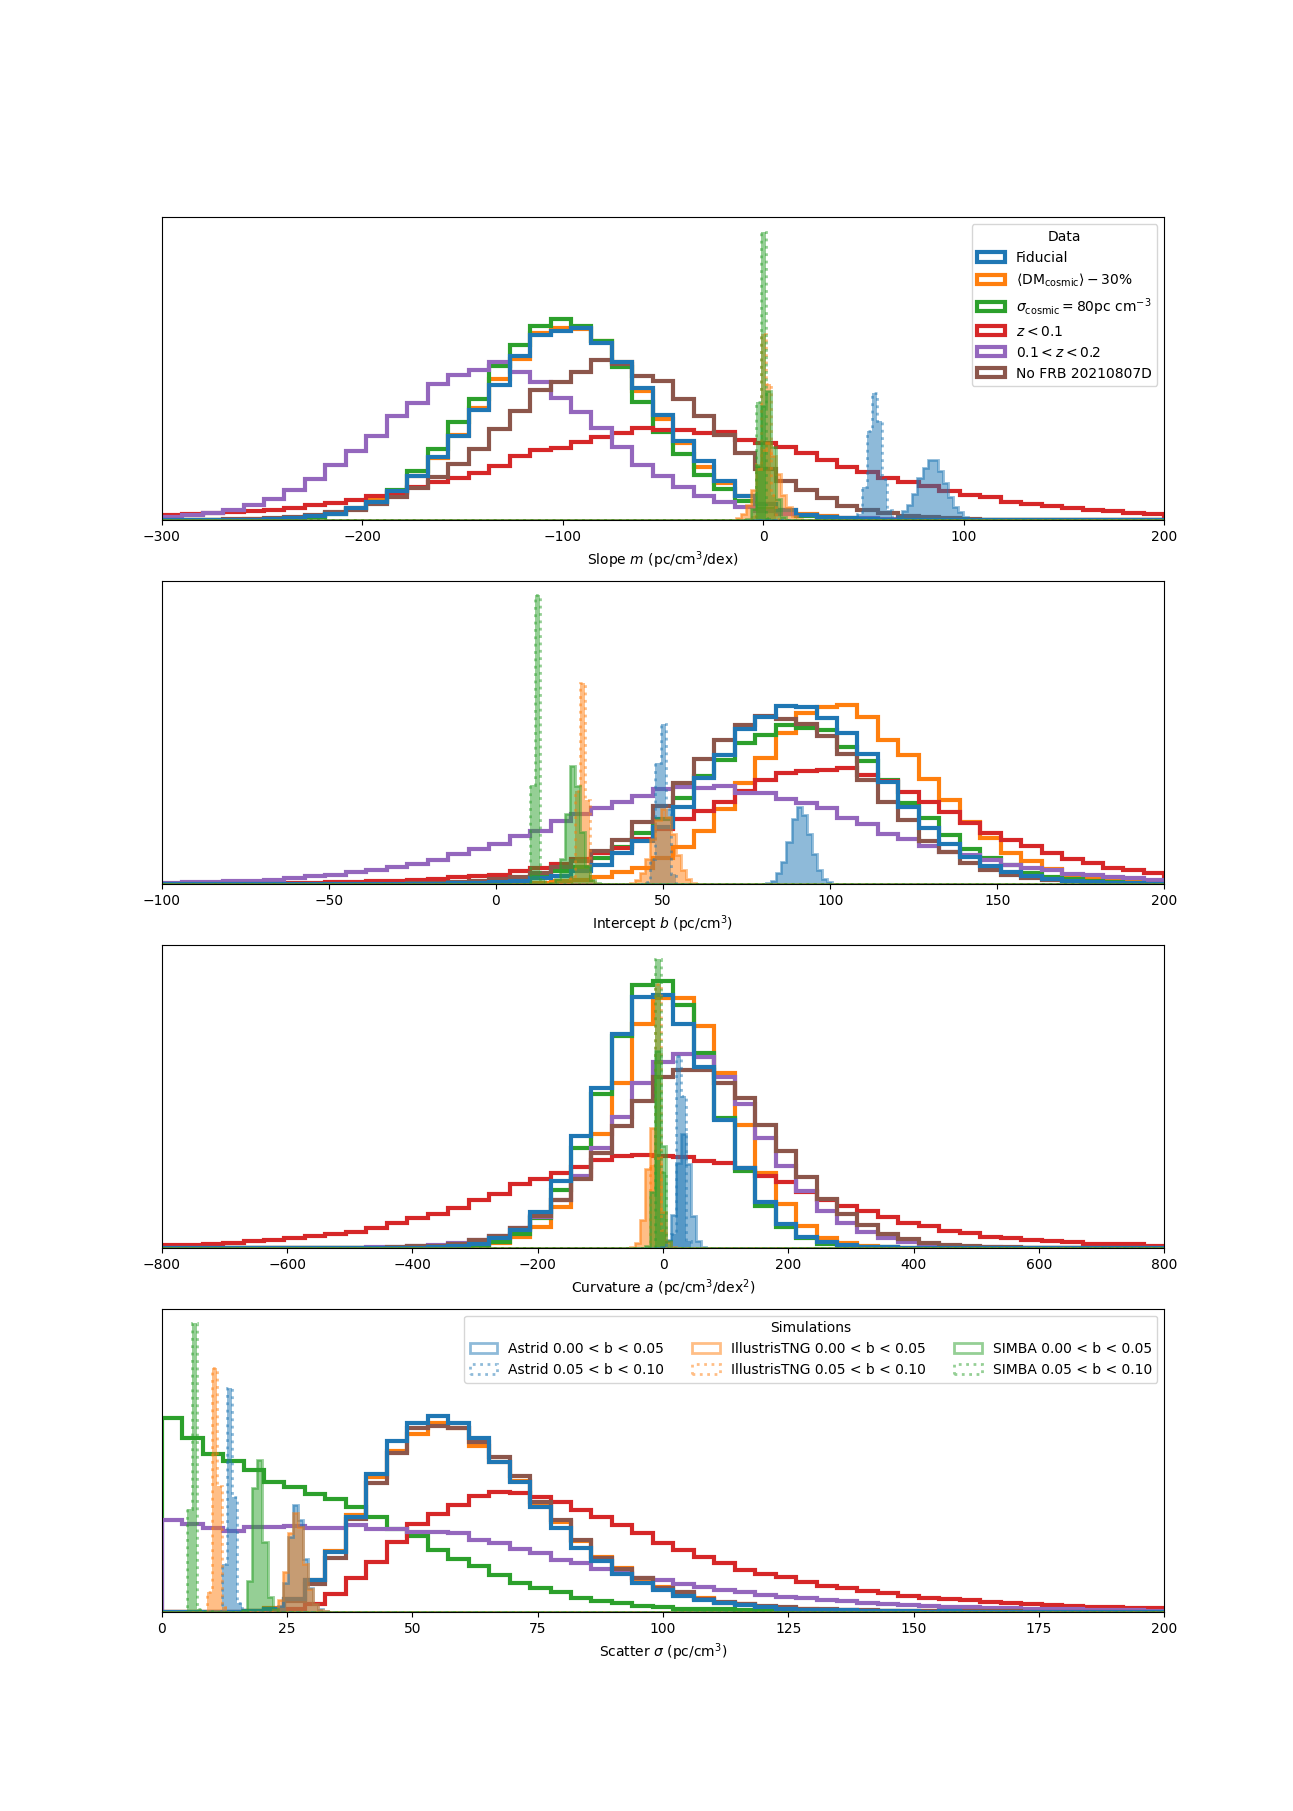

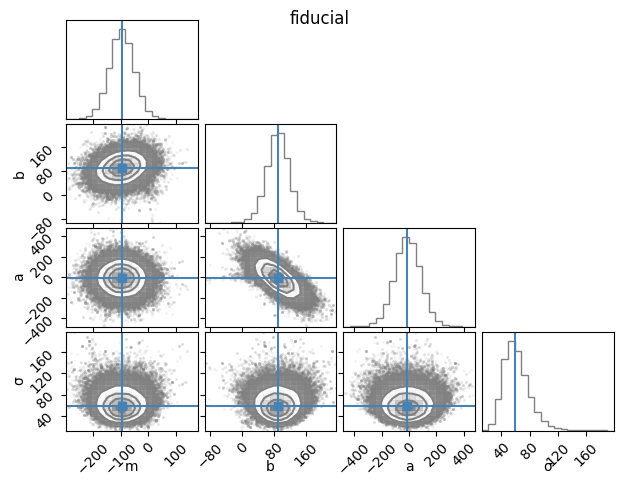

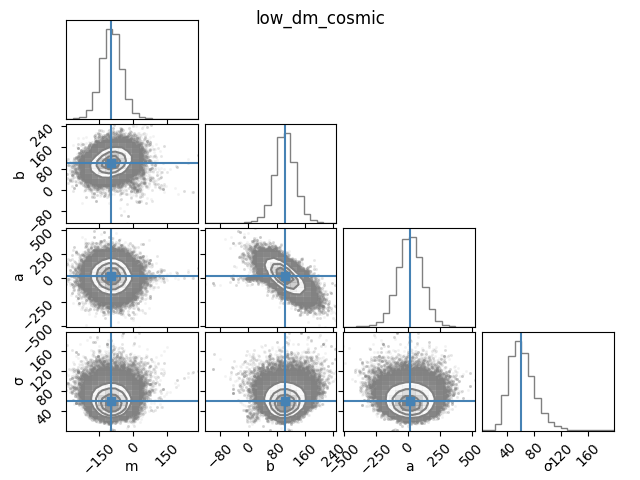

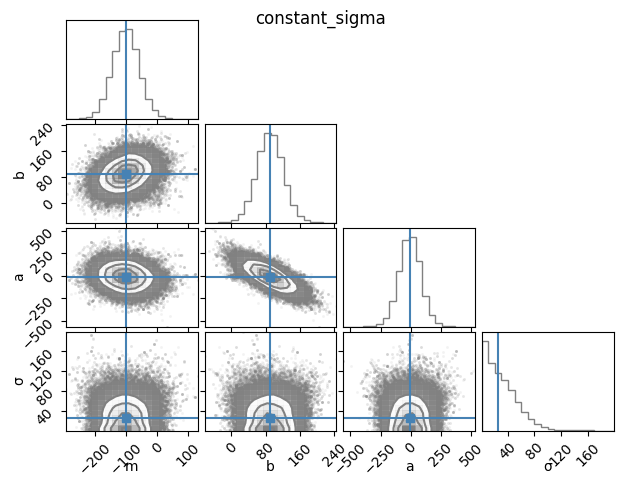

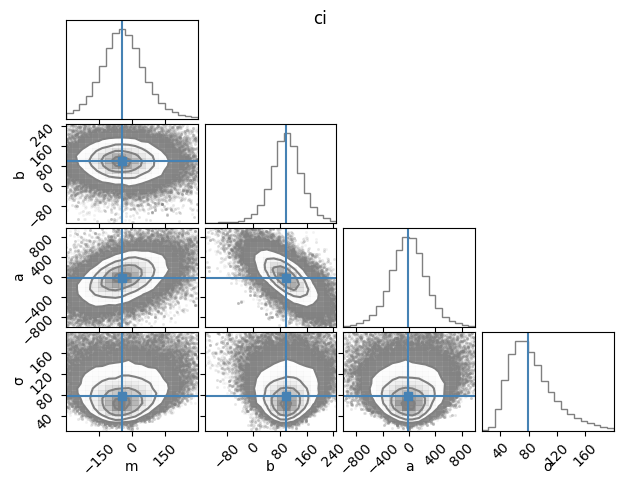

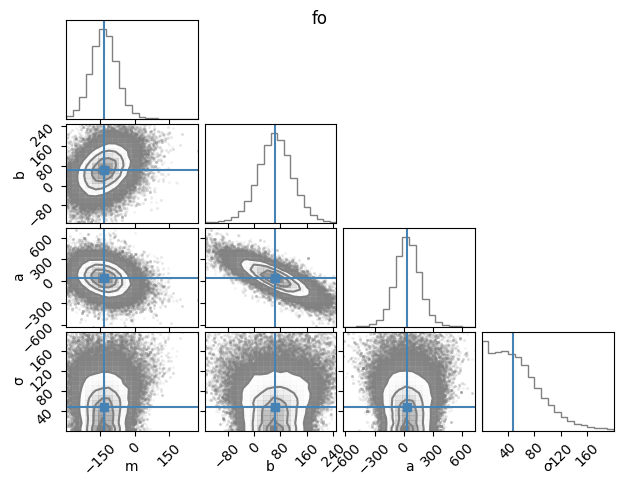

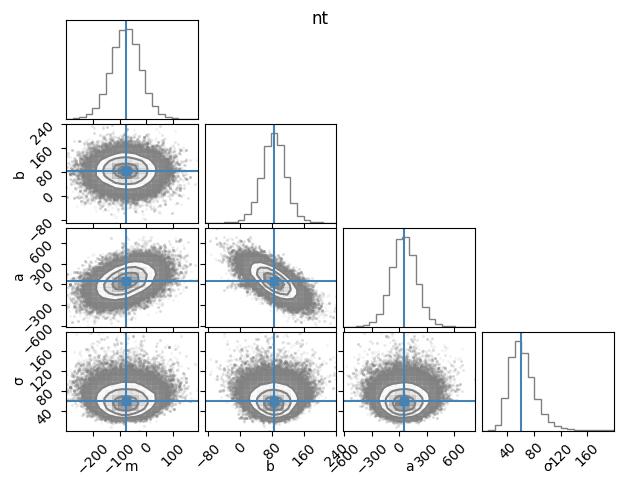

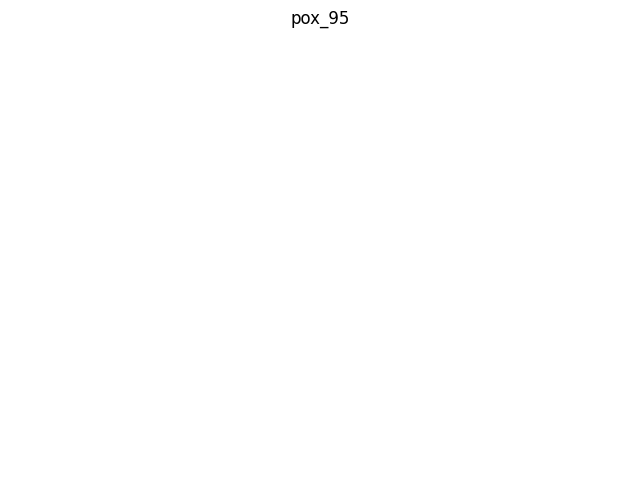

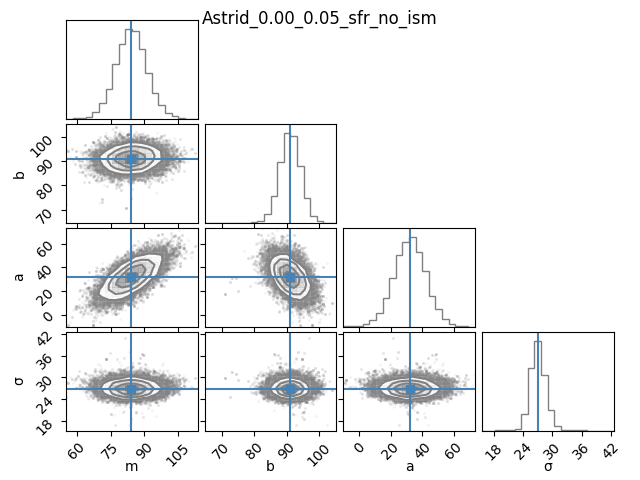

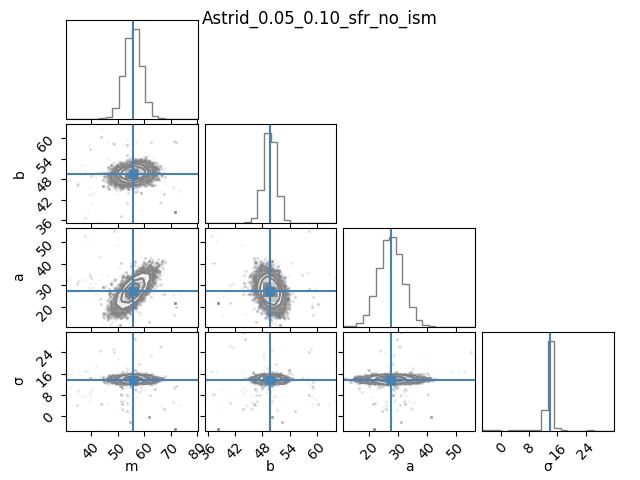

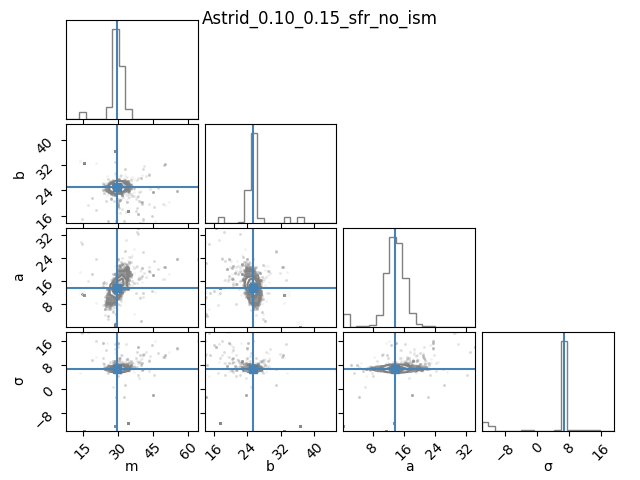

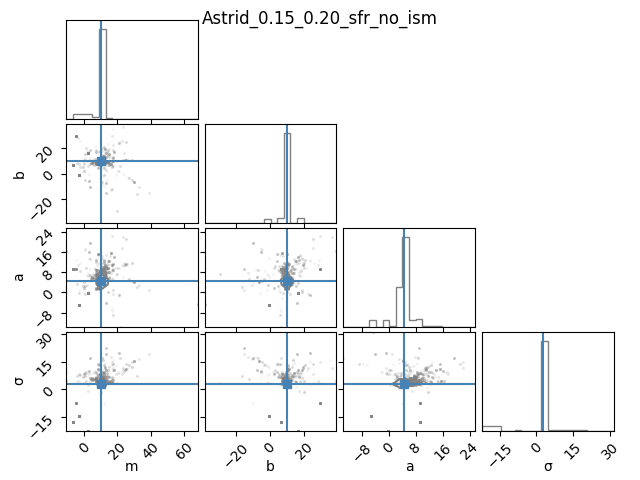

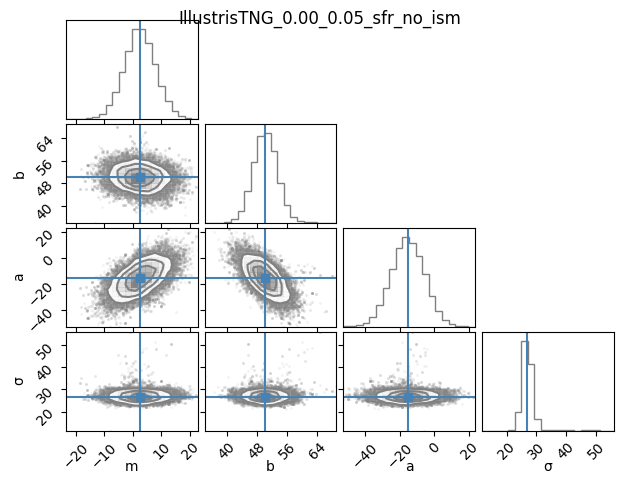

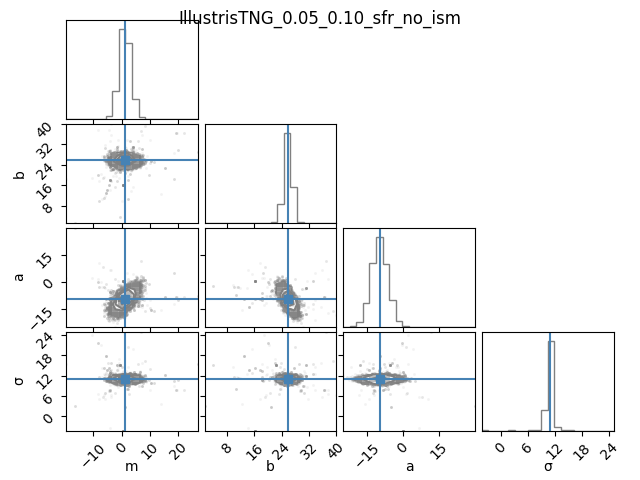

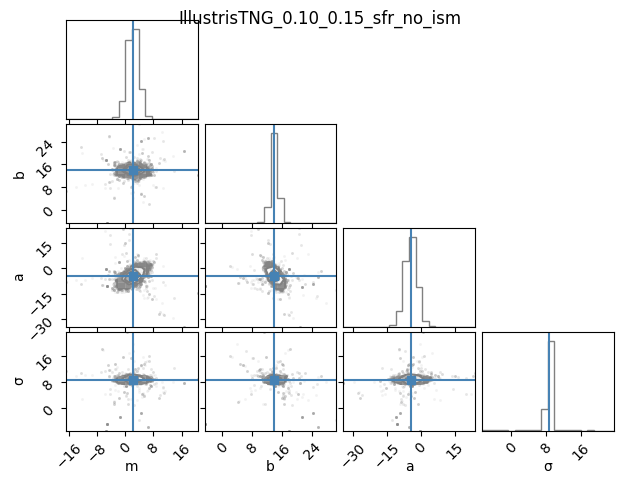

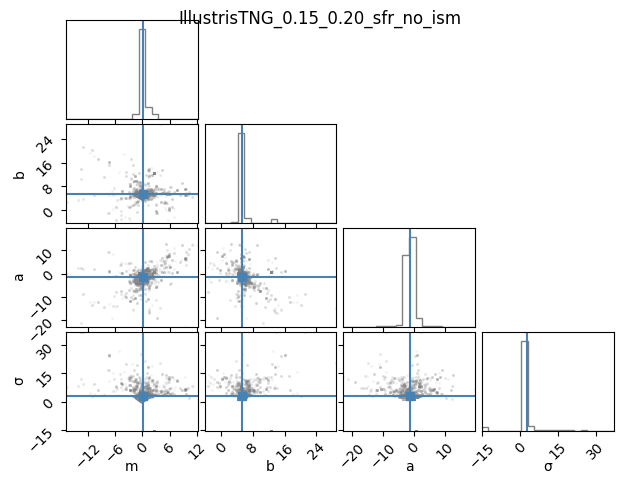

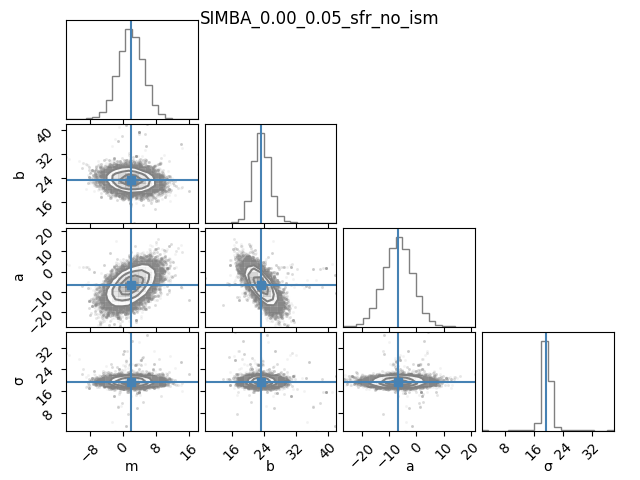

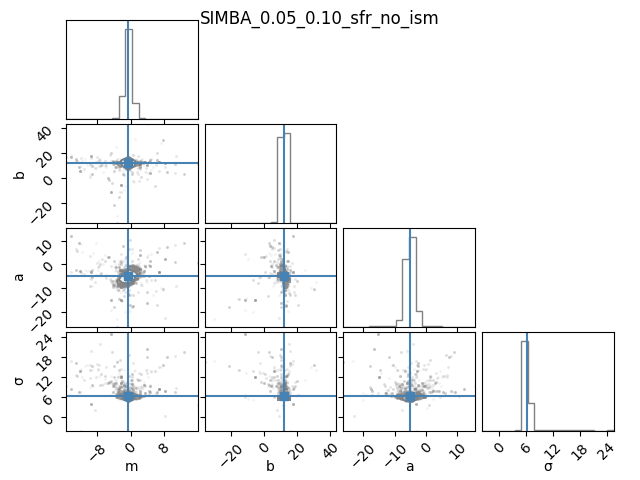

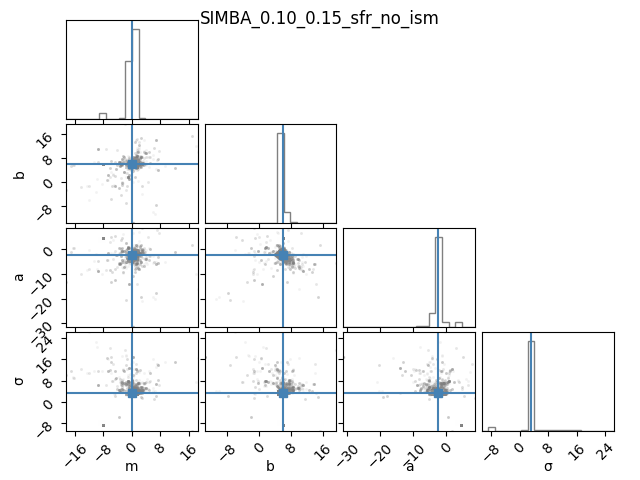

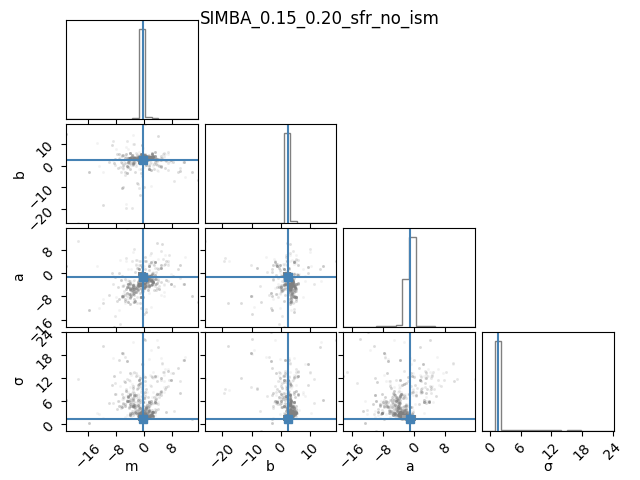

In [28]:
MAKE_AND_SAVE_PLOT = 1
table_filename = os.path.join(ROOT_PATH,"params.tex")

write_latex_header(table_filename)

SIM_VARIANTS = [
                    ('Astrid_0.00_0.05_sfr_no_ism', True),
                    ('Astrid_0.05_0.10_sfr_no_ism', True),
                    ('Astrid_0.10_0.15_sfr_no_ism',False),
                    ('Astrid_0.15_0.20_sfr_no_ism',False),
                    ('IllustrisTNG_0.00_0.05_sfr_no_ism', True),
                    ('IllustrisTNG_0.05_0.10_sfr_no_ism', True),
                    ('IllustrisTNG_0.10_0.15_sfr_no_ism',False),
                    ('IllustrisTNG_0.15_0.20_sfr_no_ism',False),
                    ('SIMBA_0.00_0.05_sfr_no_ism', True),
                    ('SIMBA_0.05_0.10_sfr_no_ism', True),
                    ('SIMBA_0.10_0.15_sfr_no_ism',False),
                    ('SIMBA_0.15_0.20_sfr_no_ism',False),
            ]

OBS_VARIANTS = [ # name of variant, and whether to plot it in Fig 4
    ('fiducial', True),
    ('low_dm_cosmic', True),
    ('constant_sigma', True),
    ('ci', True),
    ('fo', True),
    ('nt', True),
    ('pox_95', False),
]

xlabels = [r'Slope $m$ (pc/cm$^{3}$/dex)',r'Intercept $b$ (pc/cm$^{3}$)',r'Curvature $a$ (pc/cm$^{3}$/dex$^2$)',r'Scatter $\sigma$ (pc/cm$^{3}$)']

variant_names_dict = {
    'fiducial' : 'Fiducial',
    'low_dm_cosmic' : r'$\langle \mathrm{DM}_\mathrm{cosmic}\rangle - 30\%$',
    'high_dm_cosmic' : r'$\langle \mathrm{DM}_\mathrm{cosmic}\rangle + 30\%$',
    'high_sigma' : r'$\sigma_\mathrm{cosmic}$ + 50%',
    'constant_sigma' : r'$\sigma_\mathrm{cosmic} = 80 \mathrm{pc~cm}^{-3}$',
    'low_end' : r'$M^* < 10^{10} M_\odot$',
    'high_end' : r'$M^* > 10^{10} M_\odot$',
    'ci' : r'$z < 0.1$',
    'fo' : r'$0.1 < z < 0.2$',
    'pox_95' : r'P(O|x) > $0.95$',
    'nt' : 'No FRB 20210807D',
}
    
sim_variant_names_dict = {
    'Astrid_0.00_0.05_sfr_no_ism' : 'Astrid 0.00 < b < 0.05',
    'Astrid_0.05_0.10_sfr_no_ism' : 'Astrid 0.05 < b < 0.10',
    'Astrid_0.10_0.15_sfr_no_ism' : 'Astrid 0.10 < b < 0.15',
    'Astrid_0.15_0.20_sfr_no_ism' : 'Astrid 0.15 < b < 0.20',
    'IllustrisTNG_0.00_0.05_sfr_no_ism' : 'IllustrisTNG 0.00 < b < 0.05',
    'IllustrisTNG_0.05_0.10_sfr_no_ism' : 'IllustrisTNG 0.05 < b < 0.10',
    'IllustrisTNG_0.10_0.15_sfr_no_ism' : 'IllustrisTNG 0.10 < b < 0.15',
    'IllustrisTNG_0.15_0.20_sfr_no_ism' : 'IllustrisTNG 0.15 < b < 0.20',
    'SIMBA_0.00_0.05_sfr_no_ism' : 'SIMBA 0.00 < b < 0.05',
    'SIMBA_0.05_0.10_sfr_no_ism' : 'SIMBA 0.05 < b < 0.10',
    'SIMBA_0.10_0.15_sfr_no_ism' : 'SIMBA 0.10 < b < 0.15',
    'SIMBA_0.15_0.20_sfr_no_ism' : 'SIMBA 0.15 < b < 0.20'
}
if MAKE_AND_SAVE_PLOT:
    import h5py
    from cltools import mpl
    fig, axs = plt.subplots(figsize = mpl.figsize(fraction_of_textwidth = 1.99,height_per_width = 1.4),nrows = 4, ncols = 1)
    m_bins = np.linspace(-300,200, num = 50)
    b_bins = np.linspace(-100,200, num = 50)
    a_bins = np.linspace(-800,800,num = 50)
    s_bins = np.linspace(0,200,num = 50)
    bins = [m_bins,b_bins,a_bins,s_bins]

    with h5py.File( ROOT_PATH+'/data_products/mcmc_data.h5', "r") as f:
        for key,plot in OBS_VARIANTS:
            samples = f[key]['chain'][:].reshape((-1,4))[500:,:]
            _fig = plt.figure()
            print(key)
            m_mcmc, b_mcmc, a_mcmc, sigma_mcmc = get_params(samples)
            write_parameter_row(table_filename, samples, variant_names_dict[key])
            _fig.suptitle(key)
            if plot:
                corner.corner(samples, labels=["m", "b", "a","σ"], truths=[m_mcmc, b_mcmc, a_mcmc, sigma_mcmc],color = 'gray',fig = _fig,alpha = 0.1)
                for dim in range(4):
                    if dim == 0:
                        axs[dim].hist(samples[500:,dim],bins = bins[dim],label = variant_names_dict[key], histtype='step', linewidth = 3,zorder = int(key == 'fiducial'))
                    else: 
                        axs[dim].hist(samples[500:,dim],bins = bins[dim], histtype='step',linewidth = 3 ,zorder = int(key == 'fiducial'))
                    axs[dim].set_xlabel(xlabels[dim])
        axs[0].legend(title="Data")

    
    def get_hist_kwargs(name):
        out = {}
        if name.split('_')[0] == 'Astrid':
            out['color'] = 'C0'
        if name.split('_')[0] == 'IllustrisTNG':
            out['color'] = 'C1'
        if name.split('_')[0] == 'SIMBA':
            out['color'] = 'C2'
        out['alpha'] = 0.5
        out['linewidth'] = 2
        bmin = name.split('_')[1]
        if bmin == '0.00':
            out['linestyle'] = '-'
        if bmin == '0.05':
            out['linestyle'] = ':'
        if bmin == '0.10':
            out['linestyle'] = '--'
        #if bmin == '0.15':
        #    out['linestyle'] = '--'
        
        return out
    m_bins = np.linspace(-300,200, num = 200)
    b_bins = np.linspace(-100,200, num = 200)
    a_bins = np.linspace(-800,800,num = 200)
    s_bins = np.linspace(0,200,num = 200)
    bins = [m_bins,b_bins,a_bins,s_bins]
    
    with h5py.File( ROOT_PATH+'/data_products/mcmc_sims.h5', "r") as f:
        for key,plot in SIM_VARIANTS:
            samples = f[key]['chain'][:].reshape((-1,4))[::2]
            _fig = plt.figure()
            print(key)
            m_mcmc, b_mcmc, a_mcmc, sigma_mcmc = get_params(samples)
            _fig.suptitle(key)
            write_parameter_row(table_filename, samples, sim_variant_names_dict[key])
            corner.corner(samples, labels=["m", "b", "a","σ"], truths=[m_mcmc, b_mcmc, a_mcmc, sigma_mcmc],color = 'gray',fig = _fig,alpha = 0.1)
            if plot:
                kwargs = get_hist_kwargs(key)
                for dim in range(4):
                    if dim == 3:
                        axs[dim].hist(samples[500:,dim],bins = bins[dim],histtype = 'stepfilled', **kwargs,)
                        axs[dim].hist(samples[500:,dim],bins = bins[dim],label = sim_variant_names_dict[key],histtype = 'step' ,**kwargs,)
                    else: 
                        axs[dim].hist(samples[500:,dim],bins = bins[dim], histtype = 'stepfilled',**kwargs,)
                        axs[dim].hist(samples[500:,dim],bins = bins[dim], histtype = 'step',**kwargs,)
                    axs[dim].set_xlabel(xlabels[dim])
                    axs[dim].set_yticks([]) 
    axs[3].legend(ncols=3, title="Simulations")
    axs[0].set_xlim(-300,200)
    axs[1].set_xlim(-100,200)
    axs[2].set_xlim(-800,800)
    axs[3].set_xlim(0,200)
    fig.savefig(ROOT_PATH+'/figures/params_1d.pdf',dpi=110)
    fig.savefig(ROOT_PATH+'/figures/params_1d.png',dpi=110)
    caption = "MCMC parameter estimates for observed and simulated sightlines, where we fit the slope ($m$), intercept ($b$), curvature ($a$), and scatter ($\sigma$)."
    caption += " Parameters estimates from the data plotted in Fig. 3 correspond to the “Fiducial” observational sample parameters. The simulation variants shown there correspond to ``0.00 < b < 0.05''."
    close_latex_table(table_filename, caption)

